# `fire_los_recovery` — 5. The recovered fields, up close

Notebooks 01–04 established *numbers*: recovery errors, χ calibration, the
ρ_DM,☉ budget. This notebook looks at the **fields themselves** — what the
best pulsar-regime model actually believes about the Galaxy's acceleration,
potential, and density, next to the FIRE m12i truth.

**The model.** PINN **IV + BFE** — an MLP (NFW scaling) *plus* the frozen
sim-fitted Hernquist–Ostriker expansion (n,l ≤ 4) as analytic baseline —
trained on **n = 50** sightlines with **catalog noise** (`hetW`: real
Donlon+2025 σ's, whitened L1), mode **LOS + Sun + ρ** (Sun 3-D anchor +
ρ ≥ 0 hinge), stopped at the **χ-crossing** (Morozov: stop when the
whitened train misfit reaches the noise level, `χ = √(2/π) ≈ 0.798`).
That is the campaign-best n = 50 configuration: median rel. accel error
≈ 11 % in the 4-kpc training ball, 19–23 % at 15 kpc (flat in n — the BFE
baseline is the extrapolation lever).

**Provenance.** The trained weights are NOT retrained here — we load the
frozen χ-stop checkpoints written by
`experiments/fire_los_recovery/val_split_check.py --mode LOS+Sun+rho`
(`results_val_split_check_rho/checkpoints/IV_bfe_LOSSunrho_n50_t{0..5}.pkl`),
verify each against its frozen `summary.csv` row, and visualize the
**median trial**.

**Truth on new grids.** Slice/ray truth is computed the exact same way the
training labels were: pytreegrav tree summation over the full 147 M-particle
table (per-type spline softenings, θ = 0.5, quadrupoles), then the frame
correction `a → a − a_frame`, `Φ → Φ + a_frame·x − Φ(0,0,300)` with the
constants frozen in the truth-cache meta. First run costs ~3–6 min and
caches to `cache/nb05_truth_grids.npz`; re-runs are seconds.

**Figures** (all Sun-centered; dashed circle = 4 kpc training-ball edge):

| fig | what |
|---|---|
| 1 | Φ slices, 3 planes × [true, pred, residual] |
| 2 | Φ along 4 rays from the Sun + residuals |
| 3 | \|a\| slices, true / pred / rel. error |
| 4 | ρ slices, true / pred / log-ratio |
| 4b | ρ_DM slices: model total − *known* baryons vs true DM |
| 5 | ρ(z) at the solar annulus: truth vs model vs BFE baseline |
| 6 | 3-D observing geometry (the 50 sightlines + their σ's) |
| 7 | 3-D error field: slice-box + validation-star error cloud |
| 8 | 3-D slice-boxes of the ρ and ρ_DM log-ratio errors |

## Load the frozen model — and prove it's *that* model

We rebuild the IV architecture exactly as the ladder does (residual context:
`u* = max|u − u_BFE|`, `cfg["ab_potential"] = BFE`, `trainable = False`),
merge each pickled χ-crossing state, and recompute the eval that
`val_split_check.py` recorded per epoch: mean rel. error on the first 512
sun4 / sun15 validation points. Each trial must reproduce its frozen
`summary.csv` row (`rec4_chi_full`, `rec15_chi_full`) — this is the gate
that the context/scaling/architecture we rebuilt is bit-compatible with
what was trained. We then keep the **median-rec4 trial** for the figures.

In [106]:
import csv
import json
import pickle
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

HERE = Path.cwd()                       # clean_experiments/fire_sims
REPO = HERE.parents[1]
EXP = REPO / 'experiments' / 'fire_los_recovery'
CACHE = HERE / 'cache'

import jax
import jax.numpy as jnp
from flax import nnx
jax.config.update('jax_default_matmul_precision', 'highest')

sys.path.insert(0, str(EXP))            # the experiment's own modules
import datasets as fds
import run_arch_bfe_vmap as rab
from run_arch_vmap import CTX_OF_ARCH
from bfe_baseline import load_bfe
import noise as fnn

TRUTH = EXP / 'cache' / 'truth_old1gyr.npz'
ARCH, N_TRAIN, N_TRIALS = 'IV', 500, 6
MODE = 'LOSSunrho'    # 'LOSSunrho' (verified) | 'LOS' (see wrap-up caveat)
CK_DIR = EXP / {'LOSSunrho': 'results_val_split_check_rho',
                'LOS': 'results_val_split_check_legal'}[MODE] / 'checkpoints'
OBSERVER = fds.OBSERVER                 # (-8.1, 0, 0) kpc
R_TRAIN, LIM, NG = 4.0, 6.0, 120        # ball edge / half-window / grid res

FIGS = HERE / 'figs' / f'{ARCH}_n{N_TRAIN}_{MODE}'   # one folder per model
FIGS.mkdir(parents=True, exist_ok=True)

bfe_pot, BFECls, bfe_meta = load_bfe(EXP / 'cache' / 'bfe_nmax4_lmax4.npz')
m_fit = float(np.asarray(bfe_pot.m))
ctxs, truth_meta = rab.build_contexts_bfe(TRUTH, 4096, bfe_pot)
c = ctxs[CTX_OF_ARCH[ARCH]]             # 'residual' context for IV
cfg = rab.arch_cfg_bfe(ARCH, c['cfg'], bfe_pot)
x_tf, a_tf, u_tf = (cfg['x_transformer'], cfg['a_transformer'],
                    cfg['u_transformer'])

template = rab.make_model_bfe(ARCH, cfg, 0, BFECls, m_fit, fds.HALO_RS)
graphdef, _, rest = nnx.split(template, nnx.Param, ...)

# frozen per-trial references
ref = {}
with open(CK_DIR.parent / 'summary.csv') as f:
    for r in csv.DictReader(f):
        if r['arch'] == ARCH and int(r['n']) == N_TRAIN:
            ref[int(r['trial'])] = (float(r['rec4_chi_full']),
                                    float(r['rec15_chi_full']))

ev4, ev15 = c['val_scaled']['sun4'], c['val_scaled']['sun15']
x_ev = jnp.concatenate([ev4[0][:512], ev15[0][:512]])
a_ev = jnp.concatenate([ev4[1][:512], ev15[1][:512]])

states, rec4 = {}, {}
for t in range(N_TRIALS):
    with open(CK_DIR / f'{ARCH}_bfe_{MODE}_n{N_TRAIN}_t{t}.pkl',
              'rb') as fh:
        d = pickle.load(fh)
    assert d['crossed'], f'trial {t}: chi never crossed (unexpected at n=50)'
    states[t] = jax.tree.map(jnp.asarray, d['state'])
    m = nnx.merge(graphdef, states[t], rest)
    rel = (jnp.linalg.norm(m(x_ev)['acceleration'] - a_ev, axis=1)
           / jnp.linalg.norm(a_ev, axis=1))
    r4, r15 = float(jnp.mean(rel[:512])), float(jnp.mean(rel[512:]))
    d4, d15 = abs(r4 - ref[t][0]), abs(r15 - ref[t][1])
    assert d4 < 1e-5 and d15 < 1e-5, f'trial {t} drifted: {d4:.1e} {d15:.1e}'
    rec4[t] = r4
    print(f't={t}  rec4 {r4:.4f}  rec15 {r15:.4f}   '
          f'(vs summary.csv: {d4:.1e} / {d15:.1e})')

TRIAL = sorted(rec4, key=rec4.get)[N_TRIALS // 2]   # median trial
model = nnx.merge(graphdef, states[TRIAL], rest)
print(f'\nmedian trial -> TRIAL = {TRIAL}  (rec4 = {rec4[TRIAL]:.4f})')

# full-region errors of the chosen model (all 4096 pts per region)
for name in ('sun4', 'sun15', 'gc15'):
    xv, av = c['val_scaled'][name]
    rel = (jnp.linalg.norm(model(xv)['acceleration'] - av, axis=1)
           / jnp.linalg.norm(av, axis=1))
    print(f'{name:6s}: mean rel |a| err = {float(jnp.mean(rel)):.3f}  '
          f'(median {float(jnp.median(rel)):.3f})')


t=0  rec4 0.0739  rec15 0.2558   (vs summary.csv: 7.4e-09 / 2.8e-10)
t=1  rec4 0.0699  rec15 0.2581   (vs summary.csv: 2.1e-09 / 2.7e-09)
t=2  rec4 0.0721  rec15 0.1961   (vs summary.csv: 1.7e-08 / 4.4e-08)
t=3  rec4 0.0815  rec15 0.1788   (vs summary.csv: 7.8e-09 / 1.4e-08)
t=4  rec4 0.0757  rec15 0.2039   (vs summary.csv: 7.5e-09 / 3.0e-09)
t=5  rec4 0.0581  rec15 0.3366   (vs summary.csv: 7.2e-09 / 3.0e-09)

median trial -> TRIAL = 0  (rec4 = 0.0739)
sun4  : mean rel |a| err = 0.075  (median 0.061)
sun15 : mean rel |a| err = 0.263  (median 0.173)
gc15  : mean rel |a| err = 0.277  (median 0.172)


## Field evaluators in physical units — and the gauge

The model lives in scaled coordinates; every figure is physical. The
transformers are pure linear scalings (no offset), so:

- positions: `x_scaled = x_phys / x*` with `x* = 15.62 kpc`;
- acceleration: `a_phys = a_tf⁻¹(a_scaled)` [kpc/Myr²], shown in **mm/s/yr**
  (×977.79 — the pulsar-timing unit);
- potential: `Φ_phys = u_tf⁻¹(Φ_scaled)` [kpc²/Myr²], shown in **(km/s)²**;
- density: `∇²_scaled → ∇²_phys` picks up `x_fac²/u_fac = u*/x*²`, then
  `ρ = ∇²Φ / 4πG`, shown in **M☉/pc³**.

**Gauge freedom.** Training only ever sees `a = −∇Φ` (mostly just its LOS
projection), so the additive constant of Φ_pred is *not determined by
data*. Maps and profiles are therefore referenced to the Sun
(`Φ − Φ☉` for both fields); the residual map additionally removes its
best-fit constant over the training ball.

Two built-in consistency checks close the unit chain: (i) Gauss-law flux vs
the MC volume-Laplacian on the R = 2 kpc Sun sphere (independent
derivative orders, must agree); (ii) ρ_pred(Sun) should land near the known
~0.1 M☉/pc³ midplane total.

In [107]:
import astropy.units as au
from astropy.constants import G as _G_SI

G = _G_SI.to(au.kpc**3 / (au.Msun * au.Myr**2)).value      # ~4.4985e-12
KPCMYR2_TO_MMSYR = (au.kpc / au.Myr**2).to(au.mm / au.s / au.yr)  # ~977.79
U2KMS2 = (au.kpc**2 / au.Myr**2).to(au.km**2 / au.s**2)    # ~977.79^2
TO_MSUN_PC3 = 1e-9

# pure linear factors (verified offset-free: transform(0) == 0)
x_fac = float(x_tf.transform(jnp.ones((1, 3)))[0, 0])      # scaled per kpc
u_fac = float(u_tf.transform(jnp.asarray([1.0]))[0])       # scaled per kpc^2/Myr^2
assert abs(float(x_tf.transform(jnp.zeros((1, 3)))[0, 0])) < 1e-12
assert abs(float(u_tf.transform(jnp.asarray([0.0]))[0])) < 1e-12
LAP_TO_PHYS = x_fac**2 / u_fac       # scaled laplacian -> 1/Myr^2

@jax.jit
def _fields(params, xs):
    m = nnx.merge(graphdef, params, rest)
    out = m(xs)
    return out['potential'].reshape(-1), out['acceleration']

@jax.jit
def _lap(params, xs):
    m = nnx.merge(graphdef, params, rest)
    return m.compute_laplacian(xs)

CHUNK = 4096

def _chunked(fn, xyz_phys):
    xs = np.asarray(x_tf.transform(jnp.asarray(np.atleast_2d(xyz_phys))))
    outs, n = [], xs.shape[0]
    for i in range(0, n, CHUNK):
        blk = xs[i:i + CHUNK]
        pad = CHUNK - blk.shape[0]
        if pad:
            blk = np.concatenate([blk, np.repeat(blk[-1:], pad, axis=0)])
        o = fn(states[TRIAL], jnp.asarray(blk))
        outs.append(jax.tree.map(np.asarray, o))
    if isinstance(outs[0], tuple):
        return tuple(np.concatenate([o[k] for o in outs])[:n]
                     for k in range(len(outs[0])))
    return np.concatenate(outs)[:n]

def phi_pred_kms2(xyz):
    ps, _ = _chunked(_fields, xyz)
    return np.asarray(u_tf.inverse_transform(jnp.asarray(ps))) * U2KMS2

def a_pred_phys(xyz):
    _, avs = _chunked(_fields, xyz)
    return np.asarray(a_tf.inverse_transform(jnp.asarray(avs)))

def rho_pred_msun_pc3(xyz):
    lap = _chunked(_lap, xyz)
    return lap * LAP_TO_PHYS / (4 * np.pi * G) * TO_MSUN_PC3

# --- replay the n=50 training set of this trial (positions + sigmas) ------
rng = np.random.default_rng(TRIAL)
idx = rng.choice(c['x_pool'].shape[0], size=N_TRAIN, replace=False)
train_xyz = np.asarray(c['x_pool_phys'])[idx]              # physical kpc
sig_i = fnn.draw_sigmas_mmsyr(
    np.random.default_rng(9000 + 137 * TRIAL + N_TRAIN), N_TRAIN, 'het')
print(f'training set replayed: {train_xyz.shape[0]} stars, '
      f'sigma median {np.median(sig_i):.2f} mm/s/yr '
      f'[{sig_i.min():.2f}, {sig_i.max():.2f}]')

# --- consistency check 1: Gauss flux vs MC laplacian, R = 2 kpc Sun ball --
def fibonacci_sphere(n):
    i = np.arange(n) + 0.5
    ph = np.arccos(1 - 2 * i / n)
    th = np.pi * (1 + 5**0.5) * i
    return np.stack([np.cos(th) * np.sin(ph),
                     np.sin(th) * np.sin(ph), np.cos(ph)], axis=1)

R_CHK = 2.0
nhat = fibonacci_sphere(2048)
flux = np.mean(np.sum(a_pred_phys(OBSERVER + R_CHK * nhat) * nhat, axis=1))
rho_gauss = -3.0 / (4 * np.pi * G * R_CHK) * flux * TO_MSUN_PC3
rng2 = np.random.default_rng(7)
p = rng2.normal(size=(8192, 3))
p *= rng2.uniform(size=(8192, 1)) ** (1 / 3) * R_CHK / np.linalg.norm(
    p, axis=1, keepdims=True)
rho_mc = float(np.mean(rho_pred_msun_pc3(OBSERVER + p)))
print(f'<rho_tot> R=2 ball: Gauss {rho_gauss:.4f} vs MC-laplacian '
      f'{rho_mc:.4f} Msun/pc^3  (rel diff '
      f'{abs(rho_gauss - rho_mc) / abs(rho_gauss):.3f})')
assert abs(rho_gauss - rho_mc) / abs(rho_gauss) < 0.15, 'unit chain broken?'

# --- consistency check 2: local density at the Sun ------------------------
rho_sun = float(rho_pred_msun_pc3(OBSERVER[None, :])[0])
print(f'rho_pred(Sun) = {rho_sun:.4f} Msun/pc^3  (FIRE truth ~0.1)')


training set replayed: 500 stars, sigma median 1.69 mm/s/yr [0.12, 18.21]
<rho_tot> R=2 ball: Gauss 0.0328 vs MC-laplacian 0.0325 Msun/pc^3  (rel diff 0.011)
rho_pred(Sun) = 0.0496 Msun/pc^3  (FIRE truth ~0.1)


## FIRE truth on the plotting grids

One tree build serves every query point, so we assemble a single stack:
three Sun-centered planes (`xy` disk, `xz` meridional, `yz` transverse —
each 120² over ±6 kpc), four rays from the Sun (200 pts each), and the Sun
itself — then apply the frozen frame/gauge corrections from the truth-cache
meta.

Density truth can't come from a summation (it's a *local* quantity), so it
comes straight from the particles: mass histograms in a ±0.4 kpc slab
around each plane (0.1 kpc pixels), and — for fig 5 — mass in the solar
annulus `|R_GC − 8.1| < 0.5 kpc` binned in z, split by species. The low-res
contamination species (`dark2`) is excluded from density, exactly as in
notebook 04; it *is* included in the force summation (its far-field pull is
what the frame correction removes).

In [108]:
GRID_CACHE = CACHE / 'nb05_truth_grids.npz'
SLAB = 0.4                       # density-slab half-thickness [kpc]
RAY_R = np.linspace(0.0, LIM, 200)
RAYS = {'gc': np.array([1.0, 0, 0]), 'anti': np.array([-1.0, 0, 0]),
        'y': np.array([0, 1.0, 0]), 'z': np.array([0, 0, 1.0])}
RAY_LABELS = {'gc': 'Sun → GC (+x)', 'anti': 'anti-GC (−x)',
              'y': 'transverse (+y)', 'z': 'vertical (+z)'}
ZEDGES = np.linspace(-2.5, 2.5, 51)  # fig-5 z bins at the solar annulus

# Sun-centered planes: (label_a, label_b, (a,b) -> physical xyz, GC note)
PLANES = {
    'xy': ('x_Sun [kpc]', 'y_Sun [kpc]',
           lambda a, b: np.stack([a + OBSERVER[0], b, np.zeros_like(a)], -1),
           'arrow'),
    'xz': ('x_Sun [kpc]', 'z_Sun [kpc]',
           lambda a, b: np.stack([a + OBSERVER[0], np.zeros_like(a), b], -1),
           'arrow'),
    'yz': ('y_Sun [kpc]', 'z_Sun [kpc]',
           lambda a, b: np.stack([np.full_like(a, OBSERVER[0]), a, b], -1),
           'outofplane'),
}

def plane_grid(name):
    g = np.linspace(-LIM, LIM, NG)
    A, B = np.meshgrid(g, g, indexing='xy')
    return A, B, PLANES[name][2](A.ravel(), B.ravel())

blocks = {f'plane|{k}': plane_grid(k)[2] for k in PLANES}
for k, u in RAYS.items():
    blocks[f'ray|{k}'] = OBSERVER[None, :] + RAY_R[:, None] * u[None, :]
blocks['obs'] = OBSERVER[None, :].astype(np.float64)

need = True
if GRID_CACHE.exists():
    zc = np.load(GRID_CACHE)
    gm = json.loads(str(zc['meta']))
    need = not (gm.get('version') == 2 and gm['NG'] == NG
                and gm['LIM'] == LIM and gm['SLAB'] == SLAB)
if need:
    t0 = time.time()
    print('building truth grids (147M-particle tree summation, ~3-6 min)...')
    import fire_truth as ft
    tab = np.load(EXP / 'cache' / 'particles.npz')
    pos, mass, eps = tab['pos'], tab['mass'], tab['eps']
    counts = json.loads(str(tab['meta']))['counts']
    sl, i0 = {}, 0
    for s in ('gas', 'dark', 'dark2', 'star'):     # fire_truth packing order
        sl[s] = slice(i0, i0 + counts[s]); i0 += counts[s]

    # ---- density truth (histograms; local species only) ----
    payload = {}
    edges = np.linspace(-LIM, LIM, NG + 1)
    cell_vol = (2 * LIM / NG) ** 2 * 2 * SLAB          # kpc^3
    for pname in PLANES:
        for s in ('gas', 'dark', 'star'):               # species-split maps
            q = pos[sl[s]] - OBSERVER.astype(np.float32)
            if pname == 'xy':
                pa, pb, pp = q[:, 0], q[:, 1], q[:, 2]
            elif pname == 'xz':
                pa, pb, pp = q[:, 0], q[:, 2], q[:, 1]
            else:
                pa, pb, pp = q[:, 1], q[:, 2], q[:, 0]
            msk = np.abs(pp) < SLAB
            H, _, _ = np.histogram2d(pa[msk], pb[msk], bins=[edges, edges],
                                     weights=mass[sl[s]][msk])
            payload[f'rho2d|{s}|{pname}'] = (H.T / cell_vol
                                             * TO_MSUN_PC3)  # (b, a) order

    ann_vol = np.pi * (8.6**2 - 7.6**2) * np.diff(ZEDGES)  # kpc^3 per z bin
    for s in ('gas', 'dark', 'star'):
        q = pos[sl[s]]
        msk = np.abs(np.hypot(q[:, 0], q[:, 1]) - 8.1) < 0.5
        H, _ = np.histogram(q[:, 2][msk], bins=ZEDGES,
                            weights=mass[sl[s]][msk])
        payload[f'rhoz|{s}'] = H / ann_vol * TO_MSUN_PC3

    # ---- field truth: one tree summation over the full table ----
    x_q = np.vstack([blocks[k] for k in blocks])
    soft = (eps * ft.SPLINE_PER_PLUMMER).astype(np.float64)
    a_q, phi_q = ft.tree_fields(x_q, pos.astype(np.float64),
                                mass.astype(np.float64), soft,
                                truth_meta['theta'], quadrupole=True)
    fr = truth_meta['checks']['frame']
    a_frame = np.asarray(fr['a_frame_kpcmyr2'])
    a_q = a_q - a_frame[None, :]
    phi_q = phi_q + x_q @ a_frame - fr['u0_kpc2myr2']
    j0 = 0
    for k in blocks:
        n_k = blocks[k].shape[0]
        payload[f'a|{k}'] = a_q[j0:j0 + n_k]
        payload[f'phi|{k}'] = phi_q[j0:j0 + n_k]
        j0 += n_k
    payload['meta'] = np.asarray(json.dumps(
        dict(version=2, NG=NG, LIM=LIM, SLAB=SLAB,
             theta=truth_meta['theta'],
             created=time.strftime('%Y-%m-%d %H:%M'))))
    np.savez_compressed(GRID_CACHE, **payload)
    del pos, mass, eps, tab
    print(f'wrote {GRID_CACHE.name} in {time.time() - t0:.0f} s')
zc = np.load(GRID_CACHE)
print(f"truth grids: {json.loads(str(zc['meta']))}")


truth grids: {'version': 2, 'NG': 120, 'LIM': 6.0, 'SLAB': 0.4, 'theta': 0.5, 'created': '2026-08-12 11:17'}


## Evaluate the model on the same grids

One pass computes everything the figures need: Φ, **a**, and ∇²Φ→ρ on the
three planes, Φ along the rays, and per-star errors on the sun15
validation set (for the 3-D error cloud — those are *exact* truth points
from the cache, no gridding involved).

In [109]:
t0 = time.time()
F = {}                                   # per-plane fields, plot-ready
for pname in PLANES:
    A, B, xyz = plane_grid(pname)
    phi_t = zc[f'phi|plane|{pname}'].reshape(A.shape) * U2KMS2
    a_t = zc[f'a|plane|{pname}']
    phi_p = phi_pred_kms2(xyz).reshape(A.shape)
    a_p = a_pred_phys(xyz)
    mag_t = np.linalg.norm(a_t, axis=1).reshape(A.shape) * KPCMYR2_TO_MMSYR
    mag_p = np.linalg.norm(a_p, axis=1).reshape(A.shape) * KPCMYR2_TO_MMSYR
    err = (np.linalg.norm(a_p - a_t, axis=1)
           / np.linalg.norm(a_t, axis=1)).reshape(A.shape) * 100.0
    rho_bary = zc[f'rho2d|gas|{pname}'] + zc[f'rho2d|star|{pname}']
    rho_dark = zc[f'rho2d|dark|{pname}']
    F[pname] = dict(A=A, B=B, phi_t=phi_t, phi_p=phi_p, mag_t=mag_t,
                    mag_p=mag_p, err=err,
                    rho_p=rho_pred_msun_pc3(xyz).reshape(A.shape),
                    rho_t=rho_bary + rho_dark,
                    rho_bary=rho_bary, rho_dark=rho_dark)

phi_ray_t = {k: zc[f'phi|ray|{k}'] * U2KMS2 for k in RAYS}
phi_ray_p = {k: phi_pred_kms2(blocks[f'ray|{k}']) for k in RAYS}
phi_sun_t = float(zc['phi|obs'][0]) * U2KMS2
phi_sun_p = float(phi_pred_kms2(OBSERVER[None, :])[0])

# per-star validation errors (sun15) for the 3-D cloud
xv15 = np.asarray(x_tf.inverse_transform(ev15[0]))          # physical kpc
a_p15 = a_pred_phys(xv15)
a_t15 = np.asarray(a_tf.inverse_transform(ev15[1]))
err15 = (np.linalg.norm(a_p15 - a_t15, axis=1)
         / np.linalg.norm(a_t15, axis=1)) * 100.0
print(f'model evaluated on {3 * NG * NG + 4 * len(RAY_R) + len(xv15):,} '
      f'points in {time.time() - t0:.0f} s')

def plane_points(name, xyz_phys, slab=0.5):
    p = np.asarray(xyz_phys) - OBSERVER
    a, b, perp = {'xy': (p[:, 0], p[:, 1], p[:, 2]),
                  'xz': (p[:, 0], p[:, 2], p[:, 1]),
                  'yz': (p[:, 1], p[:, 2], p[:, 0])}[name]
    m = np.abs(perp) < slab
    return a[m], b[m]

def draw_overlays(ax, gc_note, pts=None):
    if pts is not None:
        ax.scatter(pts[0], pts[1], s=14, c='w', edgecolor='k', lw=0.5,
                   alpha=0.9, zorder=7)
    ax.add_patch(plt.Circle((0, 0), R_TRAIN, fill=False, ls='--', ec='k',
                            lw=1.3, alpha=0.8))
    ax.plot(0, 0, '*', color='gold', mec='k', ms=13, zorder=8)
    if gc_note == 'arrow':
        ax.annotate('', xy=(LIM * 0.92, 0), xytext=(LIM * 0.55, 0),
                    arrowprops=dict(arrowstyle='->', color='k', lw=1.4))
        ax.text(LIM * 0.72, LIM * 0.12, 'GC', fontsize=8, ha='center')
    else:
        ax.plot(0, 0, 'o', mfc='none', mec='k', ms=18, zorder=6)
        ax.text(0, -LIM * 0.9, r'$\to$GC out of plane', fontsize=7,
                ha='center')
    ax.set_xlim(-LIM, LIM); ax.set_ylim(-LIM, LIM); ax.set_aspect('equal')

ARCH_LABEL = {'III': 'PINN III (no baseline)',
              'IV': 'PINN IV+BFE'}[ARCH]
MODE_LABEL = {'LOSSunrho': 'LOS+Sun+$\\rho$', 'LOS': 'LOS-only'}[MODE]
MODEL_TAG = (f'{ARCH_LABEL} ($\\chi$-stop) | hetW catalog noise, '
             f'{MODE_LABEL} | n={N_TRAIN}, trial {TRIAL}')


model evaluated on 48,096 points in 1 s


### Fig 1 — potential slices

True and predicted columns share a color scale and the Sun-referenced gauge
`Φ − Φ☉`. The **residual column is the payload**: its best-fit constant over
the training ball is removed, and the reported number is the in-ball RMS.
Look for: small structured residual inside r < 4, growth outside, and
*anisotropy* (lobes, not rings — LOS data pins Sun-radial gradients much
better than transverse ones). Against the noiseless-parent version of this
figure (`clean_experiments/visualizations/`), the BFE baseline visibly
tames the far field.

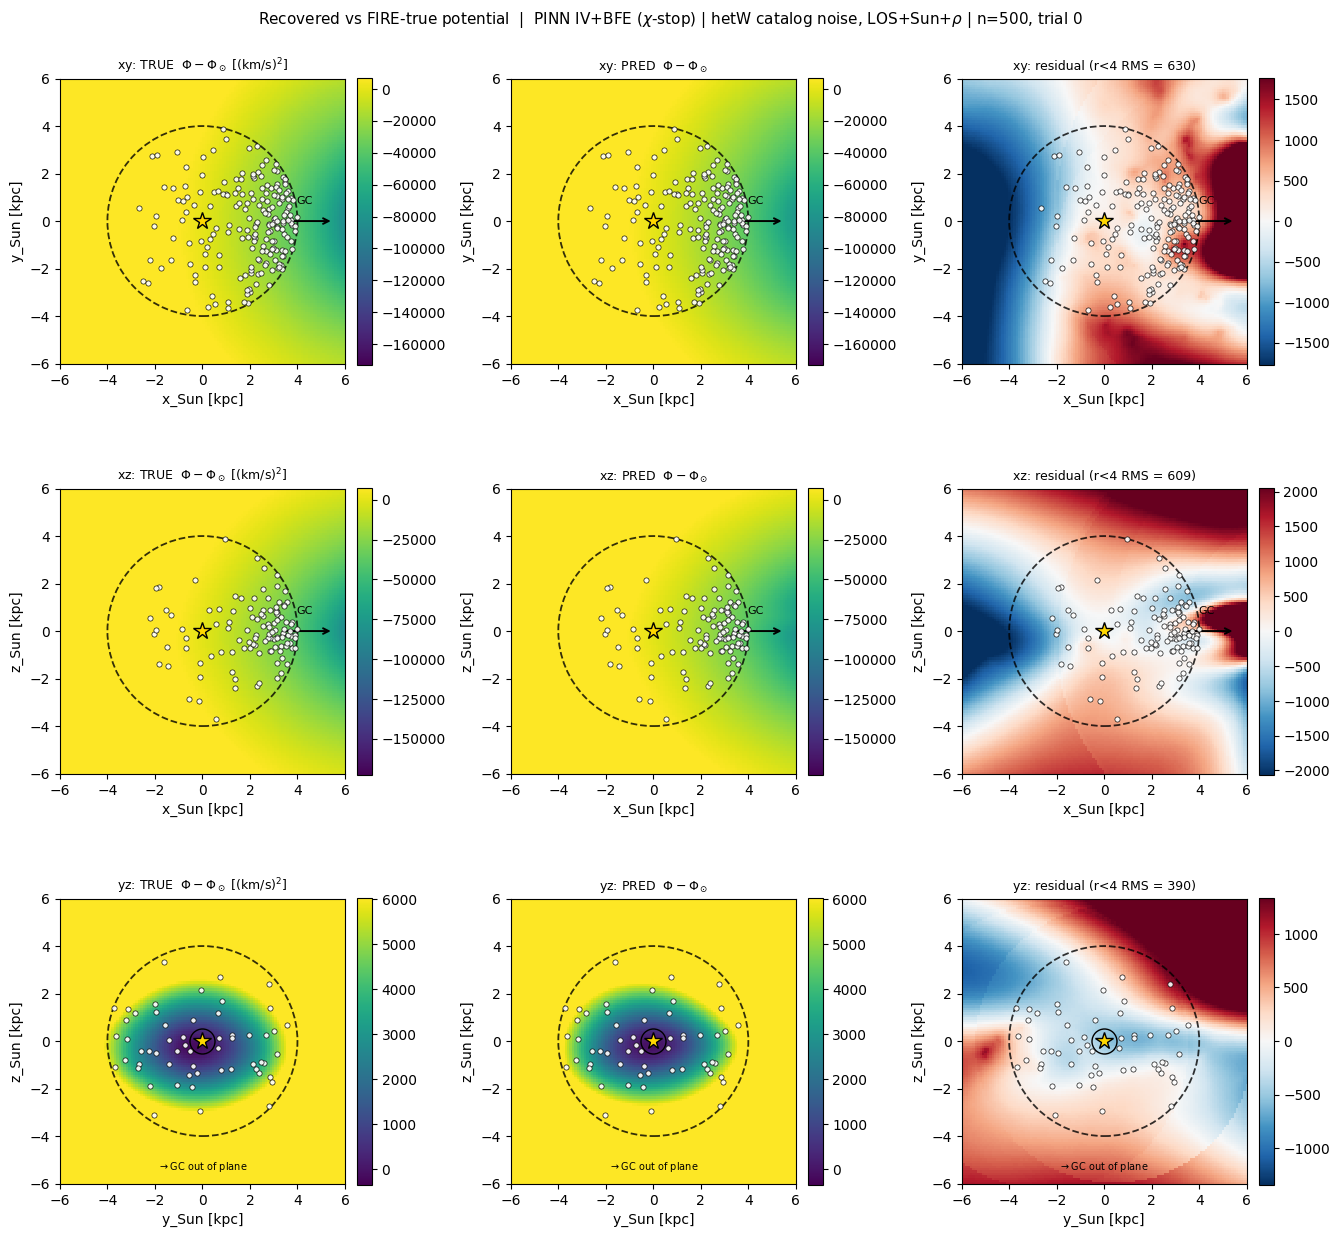

In [110]:
fig, axes = plt.subplots(3, 3, figsize=(13.5, 12.8))
for i, name in enumerate(PLANES):
    d = F[name]
    pt = d['phi_t'] - phi_sun_t
    pp = d['phi_p'] - phi_sun_p
    rr = d['phi_p'] - d['phi_t']                    # raw pred - true
    rball = np.sqrt(d['A']**2 + d['B']**2) <= R_TRAIN
    rr = rr - rr[rball].mean()
    rms = float(np.sqrt((rr[rball]**2).mean()))
    vmin, vmax = min(pt.min(), pp.min()), max(pt.max(), pp.max())
    vmin*=2
    vmax*=0.2
    lab0, lab1, _, gc = PLANES[name]
    pts = plane_points(name, train_xyz)
    m0 = axes[i, 0].pcolormesh(d['A'], d['B'], pt, cmap='viridis',
                               vmin=vmin, vmax=vmax, shading='auto')
    m1 = axes[i, 1].pcolormesh(d['A'], d['B'], pp, cmap='viridis',
                               vmin=vmin, vmax=vmax, shading='auto')
    rlim = np.abs(rr[rball]).max()
    m2 = axes[i, 2].pcolormesh(d['A'], d['B'], rr, cmap='RdBu_r',
                               vmin=-rlim, vmax=rlim, shading='auto')
    for j, mm in ((0, m0), (1, m1), (2, m2)):
        draw_overlays(axes[i, j], gc, pts=pts)
        axes[i, j].set_xlabel(lab0); axes[i, j].set_ylabel(lab1)
        fig.colorbar(mm, ax=axes[i, j], fraction=0.046, pad=0.04)
    axes[i, 0].set_title(
        f'{name}: TRUE  $\\Phi-\\Phi_\\odot$ [(km/s)$^2$]', fontsize=9)
    axes[i, 1].set_title(f'{name}: PRED  $\\Phi-\\Phi_\\odot$', fontsize=9)
    axes[i, 2].set_title(f'{name}: residual (r<4 RMS = {rms:.0f})',
                         fontsize=9)
fig.suptitle(f'Recovered vs FIRE-true potential  |  {MODEL_TAG}',
             fontsize=11)
fig.tight_layout()
fig.savefig(FIGS / 'nb05_fig1_potential_slices.png', dpi=140)
plt.show()


### Fig 2 — Φ along rays from the Sun

Solid = FIRE truth, dashed = model, gauge zeroed at the Sun. The curves
should track to r = 4 and peel apart slowly beyond — with the BFE baseline
the peel-off is far gentler than the parent NFW-free version. The
right panel shows each ray's residual; the Sun→GC direction is the
best-constrained, high-|z| the least data-supported.

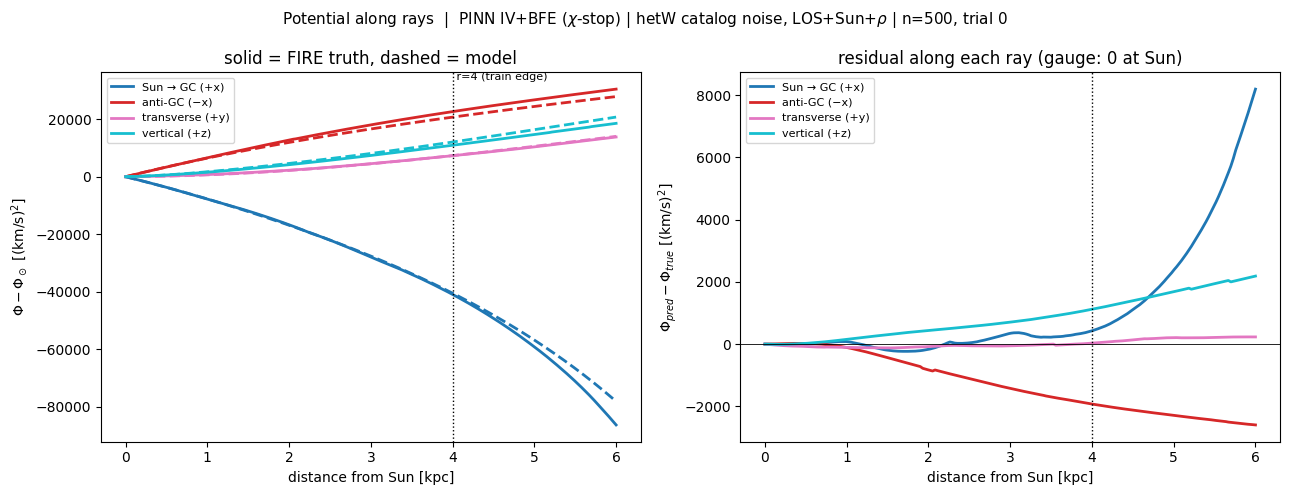

In [111]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(RAYS)))
for (k, u), col in zip(RAYS.items(), colors):
    pt = phi_ray_t[k] - phi_sun_t
    pp = phi_ray_p[k] - phi_sun_p
    axes[0].plot(RAY_R, pt, '-', color=col, lw=2, label=RAY_LABELS[k])
    axes[0].plot(RAY_R, pp, '--', color=col, lw=2)
    axes[1].plot(RAY_R, pp - pt, '-', color=col, lw=2, label=RAY_LABELS[k])
for ax in axes:
    ax.axvline(R_TRAIN, color='k', ls=':', lw=1)
    ax.set_xlabel('distance from Sun [kpc]')
axes[0].text(R_TRAIN, axes[0].get_ylim()[1], ' r=4 (train edge)',
             fontsize=8, va='top')
axes[0].set_ylabel(r'$\Phi-\Phi_\odot$ [(km/s)$^2$]')
axes[0].set_title('solid = FIRE truth, dashed = model')
axes[0].legend(fontsize=8)
axes[1].axhline(0, color='k', lw=0.6)
axes[1].set_ylabel(r'$\Phi_{pred}-\Phi_{true}$ [(km/s)$^2$]')
axes[1].set_title('residual along each ray (gauge: 0 at Sun)')
axes[1].legend(fontsize=8)
fig.suptitle(f'Potential along rays  |  {MODEL_TAG}', fontsize=11)
fig.tight_layout()
fig.savefig(FIGS / 'nb05_fig2_radial_profiles.png', dpi=140)
plt.show()


### Fig 3 — acceleration slices

The trained, gauge-free quantity, in the observable's own unit (mm/s/yr).
True and predicted |a| share a color scale per plane; the error column is
the same map `results.csv` summarizes as `rel_err`. The FIRE truth is
*grainy* (local subhalos/GMC-scale structure) — a smooth model cannot and
should not reproduce the speckle, which sets the ~5 % small-scale error
floor identified in notebook 01.

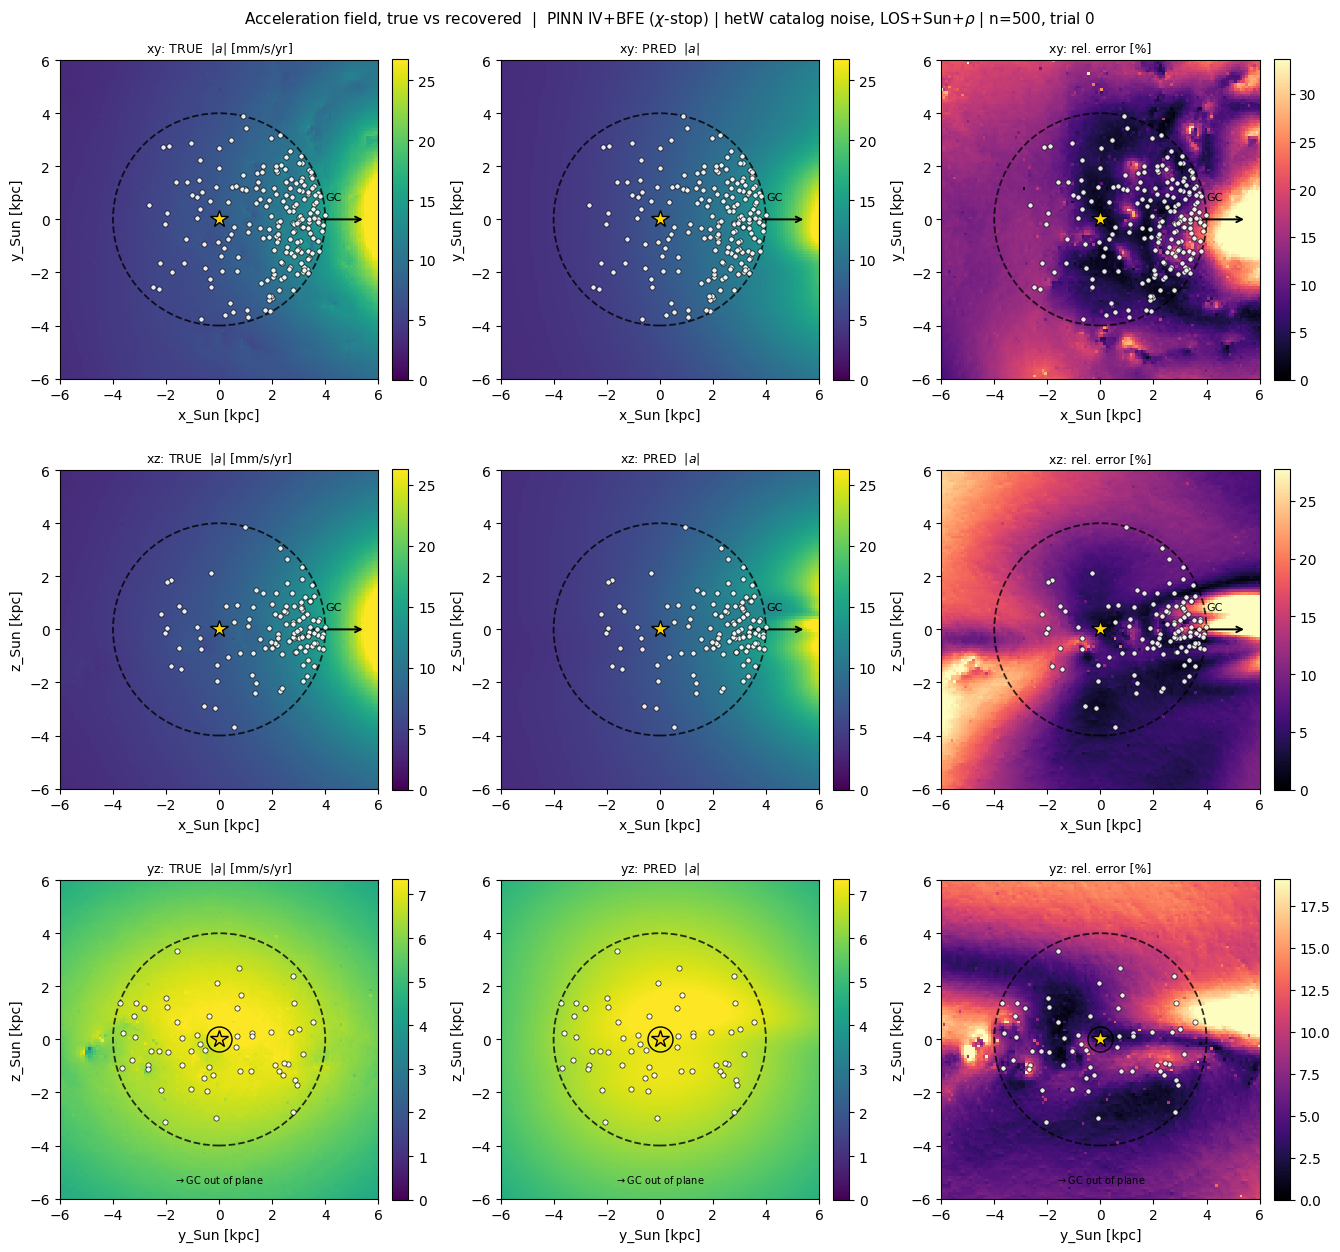

In [112]:
fig, axes = plt.subplots(3, 3, figsize=(13.5, 12.8))
for i, name in enumerate(PLANES):
    d = F[name]
    lab0, lab1, _, gc = PLANES[name]
    pts = plane_points(name, train_xyz)
    vmax = np.percentile(d['mag_t'], 99)
    m0 = axes[i, 0].pcolormesh(d['A'], d['B'], d['mag_t'], cmap='viridis',
                               vmin=0, vmax=vmax, shading='auto')
    m1 = axes[i, 1].pcolormesh(d['A'], d['B'], d['mag_p'], cmap='viridis',
                               vmin=0, vmax=vmax, shading='auto')
    m2 = axes[i, 2].pcolormesh(d['A'], d['B'], d['err'], cmap='magma',
                               vmin=0, vmax=min(60, np.percentile(d['err'],
                                                                  98)),
                               shading='auto')
    for j, mm in ((0, m0), (1, m1), (2, m2)):
        draw_overlays(axes[i, j], gc, pts=pts)
        axes[i, j].set_xlabel(lab0); axes[i, j].set_ylabel(lab1)
        fig.colorbar(mm, ax=axes[i, j], fraction=0.046, pad=0.04)
    axes[i, 0].set_title(f'{name}: TRUE  $|a|$ [mm/s/yr]', fontsize=9)
    axes[i, 1].set_title(f'{name}: PRED  $|a|$', fontsize=9)
    axes[i, 2].set_title(f'{name}: rel. error [%]', fontsize=9)
fig.suptitle(f'Acceleration field, true vs recovered  |  {MODEL_TAG}',
             fontsize=11)
fig.tight_layout()
fig.savefig(FIGS / 'nb05_fig3_accel_slices.png', dpi=140)
plt.show()


### Fig 4 — density slices

The harshest test: ρ is *curvature* of the fitted potential, two
derivatives away from the LOS data. Truth = particle mass in the ±0.4 kpc
slab (0.1 kpc pixels, lightly smoothed for display); model =
∇²Φ_pred / 4πG. Both on a shared log scale; the right column is
log₁₀(pred/true), with model pixels at ρ ≤ 0 masked gray (the ρ ≥ 0 hinge
acts only on a 512-point collocation shell — it discourages, not forbids).

Expect the model to get the *envelope* right but miss the thin disk: the
BFE baseline is l ≤ 4 (no disk), and χ-stopped models under-curve Φ — the
smoothing bias quantified in notebook 04's addendum. That bias is nearly
invisible in figs 1–3 and dominant here: field recovery and ρ extraction
sit at different bias-variance operating points.

/var/folders/qq/_c3h3m7x0cj6f8qprnj5kyjw0000gq/T/ipykernel_95800/3182536239.py:13: RuntimeWarning: invalid value encountered in log10
  np.log10(np.ma.masked_less_equal(d['rho_p'], 0)


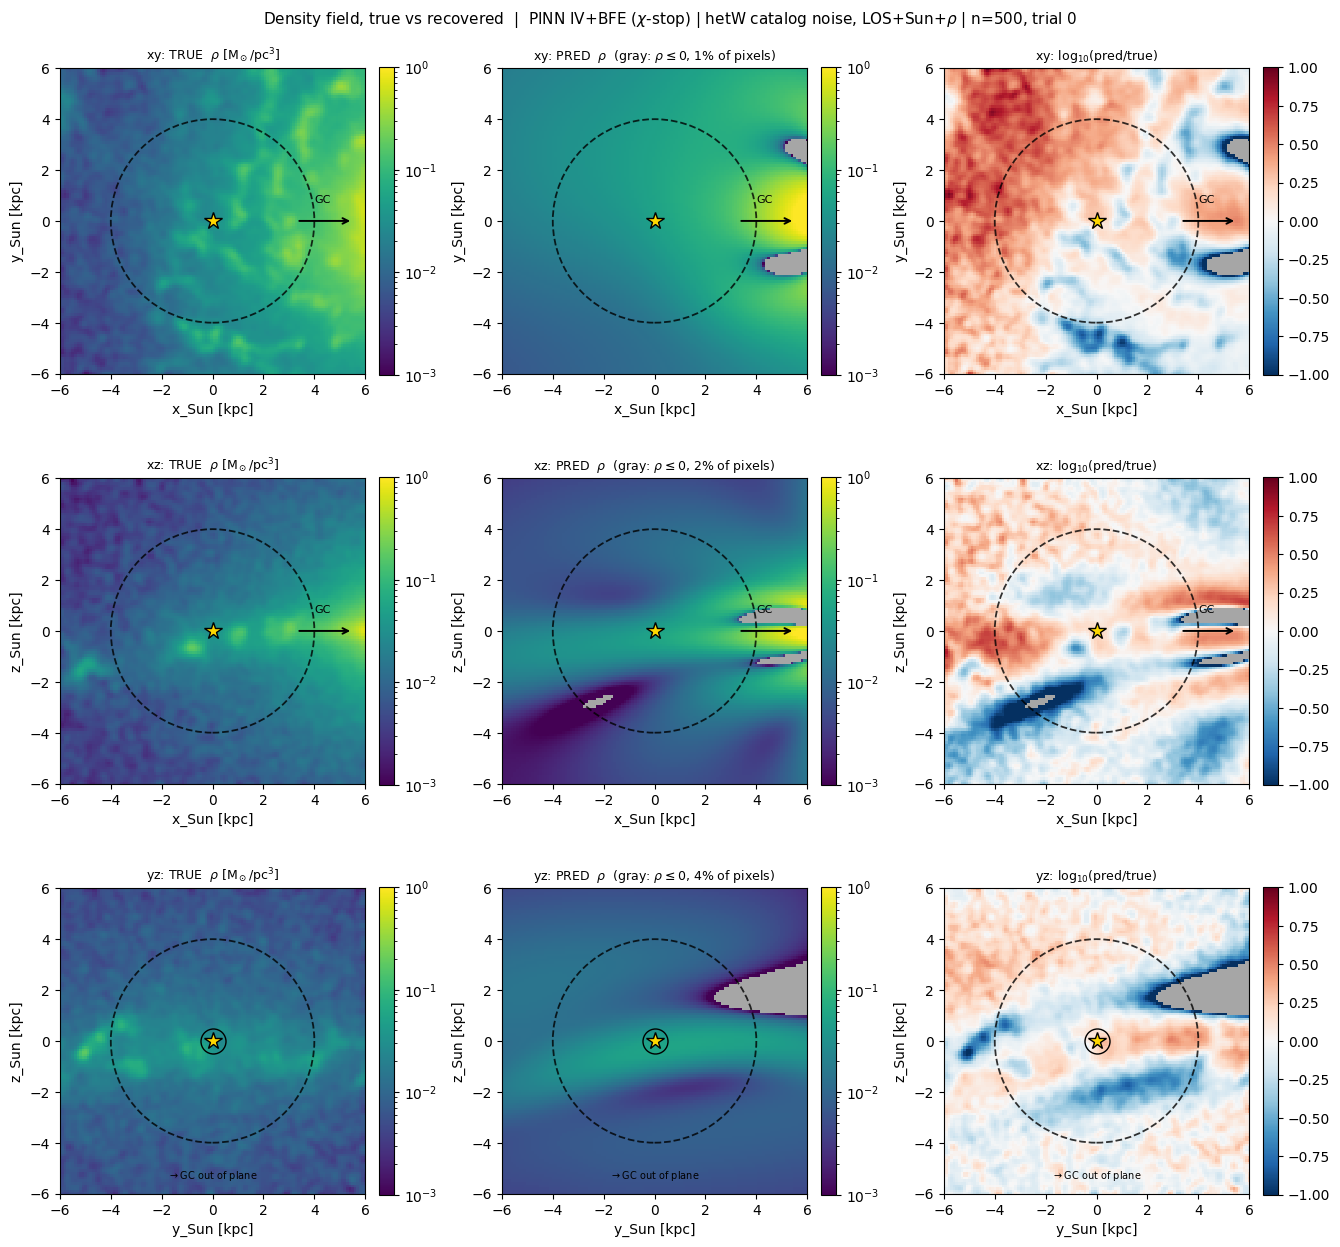

In [113]:
from matplotlib.colors import LogNorm
from scipy.ndimage import gaussian_filter

fig, axes = plt.subplots(3, 3, figsize=(13.5, 12.8))
RHO_VMIN, RHO_VMAX = 1e-3, 1
for i, name in enumerate(PLANES):
    d = F[name]
    lab0, lab1, _, gc = PLANES[name]
    rho_t = gaussian_filter(d['rho_t'], sigma=1.2)      # ~0.12 kpc display
    rho_p = np.ma.masked_less_equal(d['rho_p'], 0.0)
    neg_frac = float((d['rho_p'] <= 0).mean())
    ratio = np.ma.masked_invalid(
        np.log10(np.ma.masked_less_equal(d['rho_p'], 0)
                 / np.maximum(rho_t, 1e-6)))
    cmap_r = plt.cm.RdBu_r.copy(); cmap_r.set_bad('0.65')
    cmap_s = plt.cm.viridis.copy(); cmap_s.set_bad('0.65')
    m0 = axes[i, 0].pcolormesh(d['A'], d['B'],
                               np.maximum(rho_t, 1e-6), cmap='viridis',
                               norm=LogNorm(vmin=RHO_VMIN, vmax=RHO_VMAX),
                               shading='auto')
    m1 = axes[i, 1].pcolormesh(d['A'], d['B'], rho_p, cmap=cmap_s,
                               norm=LogNorm(vmin=RHO_VMIN, vmax=RHO_VMAX),
                               shading='auto')
    m2 = axes[i, 2].pcolormesh(d['A'], d['B'], ratio, cmap=cmap_r,
                               vmin=-1.0, vmax=1.0, shading='auto')
    for j, mm in ((0, m0), (1, m1), (2, m2)):
        draw_overlays(axes[i, j], gc)
        axes[i, j].set_xlabel(lab0); axes[i, j].set_ylabel(lab1)
        fig.colorbar(mm, ax=axes[i, j], fraction=0.046, pad=0.04)
    axes[i, 0].set_title(f'{name}: TRUE  $\\rho$ [M$_\\odot$/pc$^3$]',
                         fontsize=9)
    axes[i, 1].set_title(
        f'{name}: PRED  $\\rho$  (gray: $\\rho\\leq0$, '
        f'{100 * neg_frac:.0f}% of pixels)', fontsize=9)
    axes[i, 2].set_title(f'{name}: log$_{{10}}$(pred/true)', fontsize=9)
fig.suptitle(f'Density field, true vs recovered  |  {MODEL_TAG}',
             fontsize=11)
fig.tight_layout()
fig.savefig(FIGS / 'nb05_fig4_density_slices.png', dpi=140)
plt.show()


### Fig 4b — the DM-only density, with baryons assumed perfectly known

The map-level version of notebook 04's ρ_DM extraction, in the best case
where the baryons are *exactly* known: subtract the true baryon field from
the model's total,

$$\rho_{DM}^{pred} = \nabla^2\Phi_{pred}/4\pi G - \rho_b^{true},$$

and compare with the true DM particle field. Because ρ_DM is only ~⅓ of
ρ_tot at the midplane, every total-density error is amplified ~3× here.
Where the χ-stopped model's total falls *below* the true baryons — the
thin-disk band of fig 5 — the implied DM is negative and masked gray;
away from the disk the halo is genuinely recovered. The subtracted baryon
map and the DM truth carry the same 0.12 kpc display smoothing as fig 4.

/var/folders/qq/_c3h3m7x0cj6f8qprnj5kyjw0000gq/T/ipykernel_95800/3378209525.py:11: RuntimeWarning: invalid value encountered in log10
  ratio = np.ma.masked_invalid(np.log10(dm_p / np.maximum(dm_t, 1e-6)))


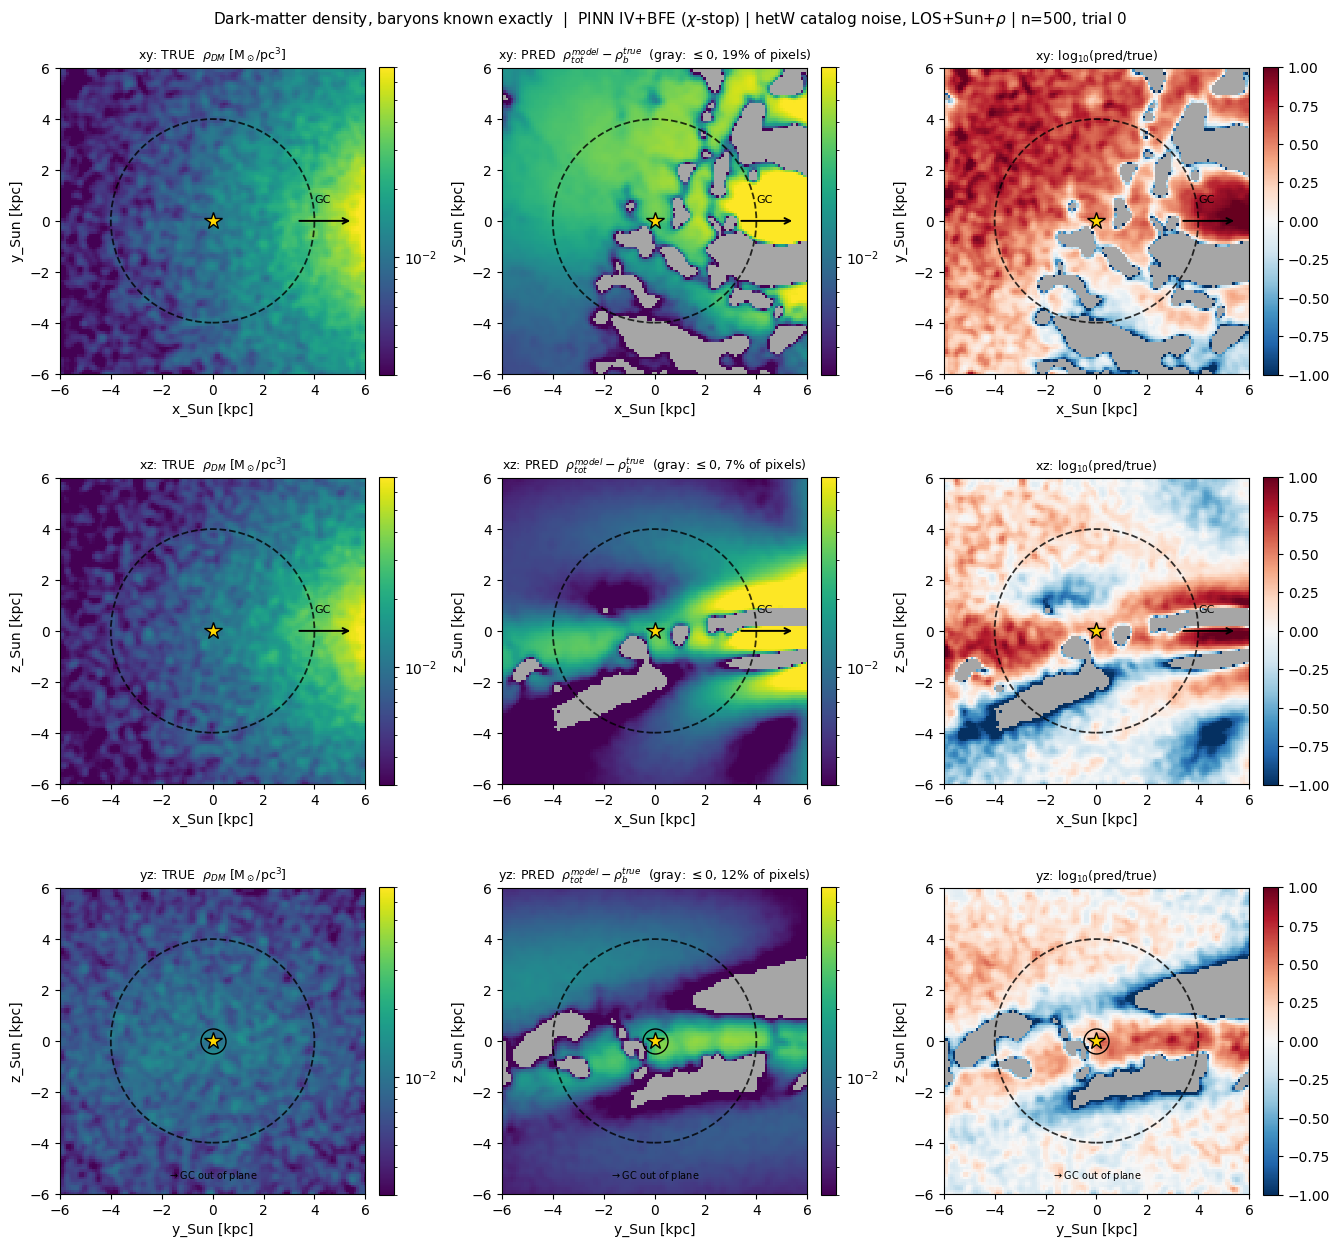

In [114]:
fig, axes = plt.subplots(3, 3, figsize=(13.5, 12.8))
RHO_VMIN_DM = 3e-3; RHO_VMAX_DM = 7e-2
for i, name in enumerate(PLANES):
    d = F[name]
    lab0, lab1, _, gc = PLANES[name]
    dm_t = gaussian_filter(d['rho_dark'], sigma=1.2)
    bary_t = gaussian_filter(d['rho_bary'], sigma=1.2)  # the 'known' baryons
    dm_raw = d['rho_p'] - bary_t
    neg_frac = float((dm_raw <= 0).mean())
    dm_p = np.ma.masked_less_equal(dm_raw, 0.0)
    ratio = np.ma.masked_invalid(np.log10(dm_p / np.maximum(dm_t, 1e-6)))
    cmap_r = plt.cm.RdBu_r.copy(); cmap_r.set_bad('0.65')
    cmap_s = plt.cm.viridis.copy(); cmap_s.set_bad('0.65')
    m0 = axes[i, 0].pcolormesh(d['A'], d['B'], np.maximum(dm_t, 1e-6),
                               cmap='viridis',
                               norm=LogNorm(vmin=RHO_VMIN_DM, vmax=RHO_VMAX_DM),
                               shading='auto')
    m1 = axes[i, 1].pcolormesh(d['A'], d['B'], dm_p, cmap=cmap_s,
                               norm=LogNorm(vmin=RHO_VMIN_DM, vmax=RHO_VMAX_DM),
                               shading='auto')
    m2 = axes[i, 2].pcolormesh(d['A'], d['B'], ratio, cmap=cmap_r,
                               vmin=-1.0, vmax=1.0, shading='auto')
    for j, mm in ((0, m0), (1, m1), (2, m2)):
        draw_overlays(axes[i, j], gc)
        axes[i, j].set_xlabel(lab0); axes[i, j].set_ylabel(lab1)
        fig.colorbar(mm, ax=axes[i, j], fraction=0.046, pad=0.04)
    axes[i, 0].set_title(
        f'{name}: TRUE  $\\rho_{{DM}}$ [M$_\\odot$/pc$^3$]', fontsize=9)
    axes[i, 1].set_title(
        f'{name}: PRED  $\\rho_{{tot}}^{{model}}-\\rho_b^{{true}}$  '
        f'(gray: $\\leq0$, {100 * neg_frac:.0f}% of pixels)', fontsize=9)
    axes[i, 2].set_title(f'{name}: log$_{{10}}$(pred/true)', fontsize=9)
fig.suptitle(f'Dark-matter density, baryons known exactly  |  {MODEL_TAG}',
             fontsize=11)
fig.tight_layout()
fig.savefig(FIGS / 'nb05_fig4b_density_dm_slices.png', dpi=140)
plt.show()


### Fig 5 — the vertical density profile at the solar annulus

The most physical 1-D cut: ρ(z) in the ring `|R_GC − 8.1| < 0.5 kpc`.
Truth is split by species (the thin stellar/gas disk vs the fat DM halo);
the model curve is the azimuthal mean of ∇²Φ_pred / 4πG on the ring; the
BFE-baseline-only curve shows what the frozen l ≤ 4 expansion contributes.
The gap between model and truth at |z| ≲ 0.3 kpc *is* the thin disk the
smooth χ-stopped fit cannot curve around — while the |z| ≳ 1 kpc behavior
(halo-dominated) is what feeds the ρ_DM story of notebook 04.

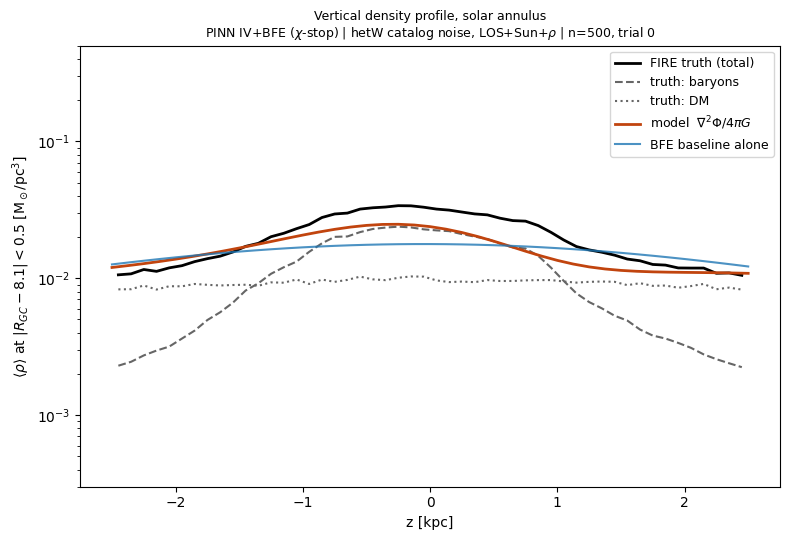

midplane: truth 0.033, model 0.024, BFE 0.018 Msun/pc^3


In [115]:
zcent = 0.5 * (ZEDGES[1:] + ZEDGES[:-1])
rz_bary = zc['rhoz|gas'] + zc['rhoz|star']
rz_dark = zc['rhoz|dark']
rz_tot = rz_bary + rz_dark

zgrid = np.linspace(-2.5, 2.5, 41)
phis = np.linspace(0, 2 * np.pi, 24, endpoint=False)
ring = np.stack([8.1 * np.cos(phis), 8.1 * np.sin(phis)], axis=1)
pts = np.concatenate([np.column_stack([ring[:, 0], ring[:, 1],
                                       np.full(len(ring), zv)])
                      for zv in zgrid])
rho_model_z = rho_pred_msun_pc3(pts).reshape(len(zgrid), -1).mean(axis=1)

def bfe_rho_msun_pc3(xyz):
    f = lambda x: bfe_pot.potential(x[None, :], 0).squeeze()
    lap = jax.vmap(lambda x: jnp.trace(jax.hessian(f)(x)))(jnp.asarray(xyz))
    return np.asarray(lap) / (4 * np.pi * G) * TO_MSUN_PC3

rho_bfe_z = bfe_rho_msun_pc3(pts).reshape(len(zgrid), -1).mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.semilogy(zcent, rz_tot, '-', color='k', lw=2, label='FIRE truth (total)')
ax.semilogy(zcent, rz_bary, '--', color='0.4', lw=1.5,
            label='truth: baryons')
ax.semilogy(zcent, rz_dark, ':', color='0.4', lw=1.5, label='truth: DM')
ax.semilogy(zgrid, np.clip(rho_model_z, 1e-5, None), '-', color='#c1440e',
            lw=2, label='model  $\\nabla^2\\Phi/4\\pi G$')
ax.semilogy(zgrid, np.clip(rho_bfe_z, 1e-5, None), '-', color='#1f77b4',
            lw=1.5, alpha=0.8, label='BFE baseline alone')
ax.set_xlabel('z [kpc]')
ax.set_ylabel(r'$\langle\rho\rangle$ at $|R_{GC}-8.1|<0.5$ '
              r'[M$_\odot$/pc$^3$]')
ax.set_ylim(3e-4, 0.5)
ax.legend(fontsize=9)
ax.set_title(f'Vertical density profile, solar annulus\n{MODEL_TAG}',
             fontsize=9)
fig.tight_layout()
fig.savefig(FIGS / 'nb05_fig5_rho_z_profile.png', dpi=140)
plt.show()
print(f'midplane: truth {rz_tot[np.abs(zcent).argmin()]:.3f}, '
      f'model {rho_model_z[np.abs(zgrid).argmin()]:.3f}, '
      f'BFE {rho_bfe_z[np.abs(zgrid).argmin()]:.3f} Msun/pc^3')


## 3-D views

### Fig 6 — the observing geometry

What the model was actually given: 50 sightlines fanning out from the Sun
to old-star tracers inside the 4-kpc ball, each carrying one noisy LOS
acceleration with its own catalog σ (line color, log scale — the darkest
lines are nearly information-free at ≳10 mm/s/yr), plus the Sun's own 3-D
acceleration as the anchor. This is the whole information budget the
fields in figs 1–5 are reconstructed from.

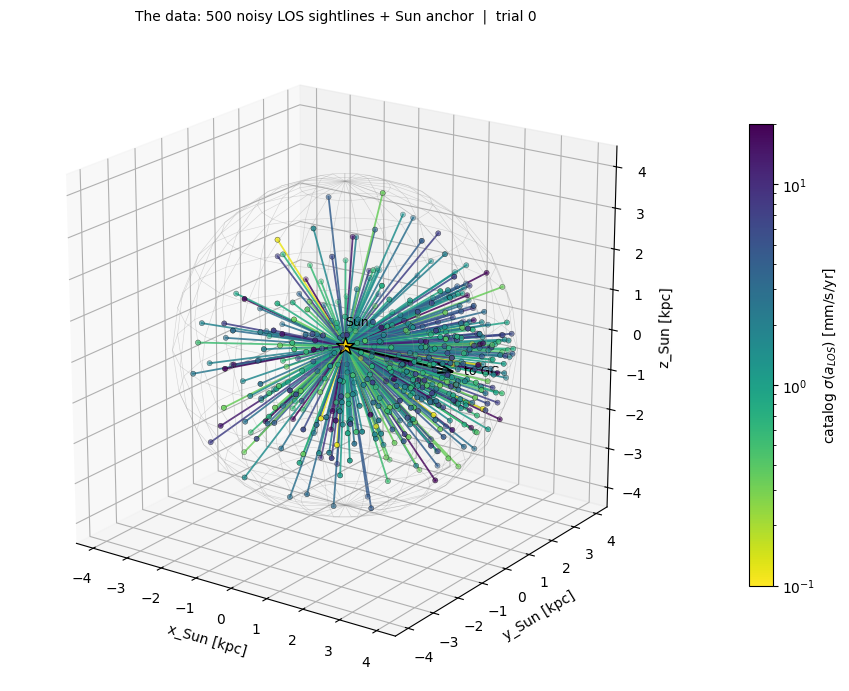

In [116]:
from matplotlib.colors import LogNorm as _LogNorm
from matplotlib import cm as _cm

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection='3d')
p_sun = train_xyz - OBSERVER
snorm = _LogNorm(vmin=0.1, vmax=20.0)
cmap = plt.cm.viridis_r                   # bright = small sigma = precise
for i in range(N_TRAIN):
    ax.plot([0, p_sun[i, 0]], [0, p_sun[i, 1]], [0, p_sun[i, 2]],
            color=cmap(snorm(sig_i[i])), lw=1.3, alpha=0.85)
ax.scatter(p_sun[:, 0], p_sun[:, 1], p_sun[:, 2], s=14,
           c=sig_i, cmap=cmap, norm=snorm, edgecolor='k', lw=0.3)
uu, vv = np.meshgrid(np.linspace(0, 2 * np.pi, 24),
                     np.linspace(0, np.pi, 13))
ax.plot_wireframe(R_TRAIN * np.cos(uu) * np.sin(vv),
                  R_TRAIN * np.sin(uu) * np.sin(vv),
                  R_TRAIN * np.cos(vv), color='0.6', lw=0.4, alpha=0.4)
ax.scatter([0], [0], [0], marker='*', s=180, c='gold', edgecolor='k',
           zorder=9)
ax.text(0, 0, 0.5, 'Sun', fontsize=9)
ax.quiver(0, 0, 0, 3.0, 0, 0, color='k', arrow_length_ratio=0.15, lw=1.5)
ax.text(3.3, 0, 0, 'to GC', fontsize=9)
sm = _cm.ScalarMappable(norm=snorm, cmap=cmap)
fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.1,
             label=r'catalog $\sigma(a_{LOS})$ [mm/s/yr]')
ax.set_xlabel('x_Sun [kpc]'); ax.set_ylabel('y_Sun [kpc]')
ax.set_zlabel('z_Sun [kpc]')
lim3 = 4.5
ax.set_xlim(-lim3, lim3); ax.set_ylim(-lim3, lim3); ax.set_zlim(-lim3, lim3)
ax.set_box_aspect((1, 1, 1))
ax.view_init(elev=20, azim=-55)
ax.set_title(f'The data: {N_TRAIN} noisy LOS sightlines + Sun anchor  |  '
             f'trial {TRIAL}', fontsize=10)
fig.tight_layout()
fig.savefig(FIGS / 'nb05_fig6_3d_geometry.png', dpi=140)
plt.show()


### Fig 7 — the error field in 3-D

Left: the three through-Sun |a|-error slices of fig 3 folded onto the faces
of a box (floor = disk plane, walls = meridional/transverse planes), with
the training stars in the volume. Right: the 4096 sun15 validation stars —
*exact* truth points, no gridding — colored by their individual rel. error.
The cloud makes the visibility structure three-dimensional: the low-error
core hugging the data ball, and the anisotropic growth pattern outside it
(the angle-only null space of LOS data — transverse directions degrade
first).

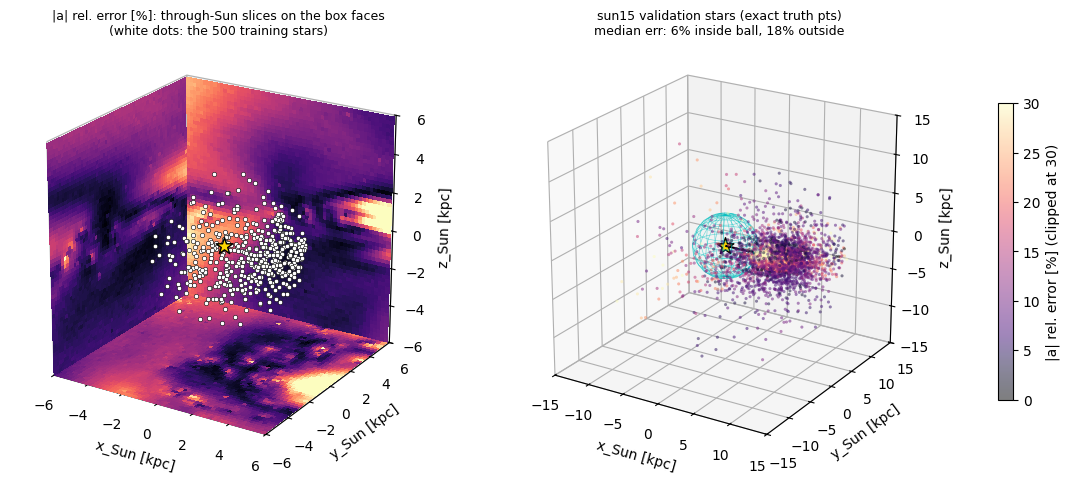

In [117]:
from matplotlib.colors import Normalize

enorm = Normalize(vmin=0, vmax=30)
fig = plt.figure(figsize=(15, 7))

ax = fig.add_subplot(121, projection='3d')
ax.computed_zorder = False               # else the faces depth-sort OVER
st = 2                                   # the dots; facet stride below
for name, (fix, sgn) in {'xy': ('z', -1), 'xz': ('y', +1),
                         'yz': ('x', -1)}.items():
    d = F[name]
    A, B, E = d['A'][::st, ::st], d['B'][::st, ::st], d['err'][::st, ::st]
    Cface = plt.cm.magma(enorm(E))
    flat = np.full_like(A, sgn * LIM)
    if name == 'xy':
        X, Y, Z = A, B, flat             # floor at z = -6
    elif name == 'xz':
        X, Y, Z = A, flat, B             # back wall at y = +6
    else:
        X, Y, Z = flat, A, B             # side wall at x = -6
    ax.plot_surface(X, Y, Z, facecolors=Cface, shade=False, rstride=1,
                    cstride=1, linewidth=0, antialiased=False, zorder=1)
ax.scatter(p_sun[:, 0], p_sun[:, 1], p_sun[:, 2], s=10, c='w',
           edgecolor='k', lw=0.4, depthshade=False, zorder=10)
ax.scatter([0], [0], [0], marker='*', s=160, c='gold', edgecolor='k',
           zorder=11)
ax.set_xlabel('x_Sun [kpc]'); ax.set_ylabel('y_Sun [kpc]')
ax.set_zlabel('z_Sun [kpc]')
ax.set_xlim(-LIM, LIM); ax.set_ylim(-LIM, LIM); ax.set_zlim(-LIM, LIM)
ax.set_box_aspect((1, 1, 1)); ax.view_init(elev=22, azim=-58)
ax.set_title(f'|a| rel. error [%]: through-Sun slices on the box faces\n'
             f'(white dots: the {N_TRAIN} training stars)', fontsize=9)

ax2 = fig.add_subplot(122, projection='3d')
pv = xv15 - OBSERVER
sc = ax2.scatter(pv[:, 0], pv[:, 1], pv[:, 2], c=np.clip(err15, 0, 30),
                 cmap='magma', norm=enorm, s=5, alpha=0.5, lw=0)
ax2.plot_wireframe(R_TRAIN * np.cos(uu) * np.sin(vv),
                   R_TRAIN * np.sin(uu) * np.sin(vv),
                   R_TRAIN * np.cos(vv), color='c', lw=0.5, alpha=0.5)
ax2.scatter([0], [0], [0], marker='*', s=160, c='gold', edgecolor='k')
ax2.quiver(0, 0, 0, 5, 0, 0, color='k', arrow_length_ratio=0.1, lw=1.5)
ax2.text(5.5, 0, 0, 'GC', fontsize=9)
in4 = np.linalg.norm(pv, axis=1) < R_TRAIN
ax2.set_title(f'sun15 validation stars (exact truth pts)\n'
              f'median err: {np.median(err15[in4]):.0f}% inside ball, '
              f'{np.median(err15[~in4]):.0f}% outside', fontsize=9)
ax2.set_xlabel('x_Sun [kpc]'); ax2.set_ylabel('y_Sun [kpc]')
ax2.set_zlabel('z_Sun [kpc]')
lim15 = 15.0
ax2.set_xlim(-lim15, lim15); ax2.set_ylim(-lim15, lim15)
ax2.set_zlim(-lim15, lim15)
ax2.set_box_aspect((1, 1, 1)); ax2.view_init(elev=22, azim=-58)
fig.colorbar(sc, ax=[ax, ax2], shrink=0.55, pad=0.06,
             label='|a| rel. error [%] (clipped at 30)')
fig.savefig(FIGS / 'nb05_fig7_3d_error_field.png', dpi=140)
plt.show()


### Fig 8 — the density-error field in 3-D

Fig 7's left panel, repeated for the two hardest quantities: the through-Sun
slices folded onto the box faces now carry **log₁₀(pred/true)** for the
total density (left) and for the DM density with baryons assumed exactly
known (right) — the same error maps as the right columns of figs 4 and 4b,
±1 dex, with pixels where the model's density (or implied DM) is ≤ 0 masked
gray. Seen together in 3-D, the disk-plane failure is unmistakable: the
gray/blue under-density band lives on the floor (disk) face and along the
midplane stripe of both walls — the thin disk the smooth χ-stopped fit
can't curve around — and the ~3× error amplification of the DM subtraction
turns the modest fig-4 residuals into the much louder right panel.

/var/folders/qq/_c3h3m7x0cj6f8qprnj5kyjw0000gq/T/ipykernel_95800/1320527294.py:12: RuntimeWarning: invalid value encountered in log10
  np.log10(np.ma.masked_less_equal(d['rho_p'], 0)
/var/folders/qq/_c3h3m7x0cj6f8qprnj5kyjw0000gq/T/ipykernel_95800/1320527294.py:15: RuntimeWarning: invalid value encountered in log10
  np.log10(np.ma.masked_less_equal(d['rho_p'] - bary_t, 0)


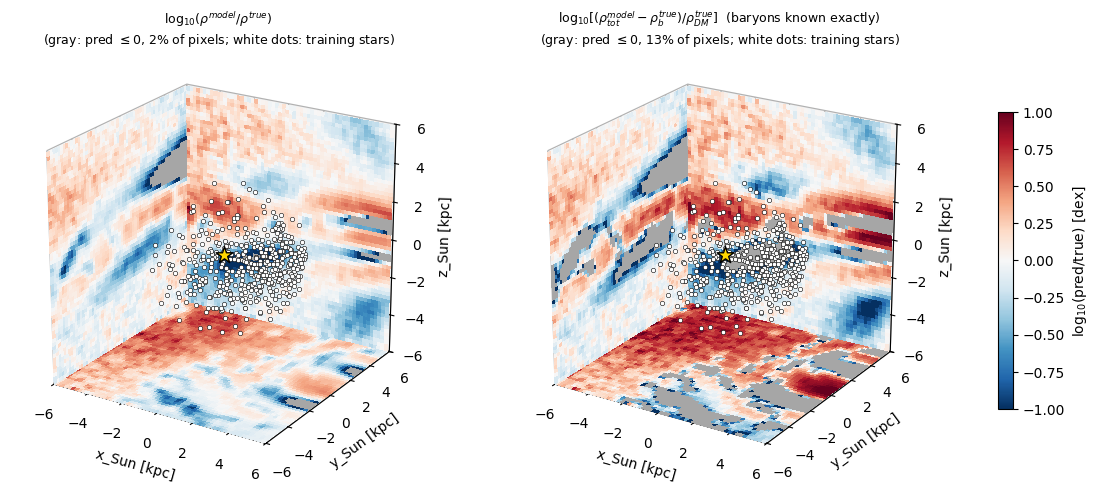

In [118]:
from matplotlib.colors import Normalize
from scipy.ndimage import gaussian_filter

# per-plane log10(pred/true) maps, masked where the numerator is <= 0
RATIO_MAPS = {'tot': {}, 'dm': {}}
for name in PLANES:
    d = F[name]
    rho_t = gaussian_filter(d['rho_t'], sigma=1.2)      # same display
    dm_t = gaussian_filter(d['rho_dark'], sigma=1.2)    # smoothing as
    bary_t = gaussian_filter(d['rho_bary'], sigma=1.2)  # figs 4/4b
    RATIO_MAPS['tot'][name] = np.ma.masked_invalid(
        np.log10(np.ma.masked_less_equal(d['rho_p'], 0)
                 / np.maximum(rho_t, 1e-6)))
    RATIO_MAPS['dm'][name] = np.ma.masked_invalid(
        np.log10(np.ma.masked_less_equal(d['rho_p'] - bary_t, 0)
                 / np.maximum(dm_t, 1e-6)))

rnorm = Normalize(vmin=-1.0, vmax=1.0)
cmap_face = plt.cm.RdBu_r.copy(); cmap_face.set_bad('0.65')
PANELS = {
    'tot': 'log$_{10}(\\rho^{model}/\\rho^{true})$',
    'dm': ('log$_{10}[(\\rho_{tot}^{model}-\\rho_b^{true})'
           '/\\rho_{DM}^{true}]$  (baryons known exactly)'),
}

fig = plt.figure(figsize=(15, 7))
st = 2
for k, key in enumerate(PANELS):
    ax = fig.add_subplot(1, 2, k + 1, projection='3d')
    ax.computed_zorder = False
    for name, sgn in {'xy': -1, 'xz': +1, 'yz': -1}.items():
        d = F[name]
        A, B = d['A'][::st, ::st], d['B'][::st, ::st]
        Cface = cmap_face(rnorm(RATIO_MAPS[key][name][::st, ::st]))
        flat = np.full_like(A, sgn * LIM)
        if name == 'xy':
            X, Y, Z = A, B, flat             # floor at z = -6
        elif name == 'xz':
            X, Y, Z = A, flat, B             # back wall at y = +6
        else:
            X, Y, Z = flat, A, B             # side wall at x = -6
        ax.plot_surface(X, Y, Z, facecolors=Cface, shade=False, rstride=1,
                        cstride=1, linewidth=0, antialiased=False, zorder=1)
    ax.scatter(p_sun[:, 0], p_sun[:, 1], p_sun[:, 2], s=10, c='w',
               edgecolor='k', lw=0.4, depthshade=False, zorder=10)
    ax.scatter([0], [0], [0], marker='*', s=160, c='gold', edgecolor='k',
               zorder=11)
    ax.set_xlabel('x_Sun [kpc]'); ax.set_ylabel('y_Sun [kpc]')
    ax.set_zlabel('z_Sun [kpc]')
    ax.set_xlim(-LIM, LIM); ax.set_ylim(-LIM, LIM); ax.set_zlim(-LIM, LIM)
    ax.set_box_aspect((1, 1, 1)); ax.view_init(elev=22, azim=-58)
    neg = np.mean([np.mean(RATIO_MAPS[key][n].mask) for n in PLANES])
    ax.set_title(f'{PANELS[key]}\n(gray: pred $\\leq0$, '
                 f'{100 * neg:.0f}% of pixels; white dots: training stars)',
                 fontsize=9)
sm = _cm.ScalarMappable(norm=rnorm, cmap=cmap_face)
fig.colorbar(sm, ax=fig.axes, shrink=0.55, pad=0.06,
             label='log$_{10}$(pred/true) [dex]')
fig.savefig(FIGS / 'nb05_fig8_3d_density_error.png', dpi=140)
plt.show()


## What to take away

1. **The potential is easy, the density is hard.** Φ (figs 1–2) is
   recovered to a few-(km/s)² RMS inside the ball; |a| (fig 3) to ~11 %;
   ρ (figs 4–5) inherits two derivatives of amplification — the thin disk
   is essentially absent from the model (l ≤ 4 baseline + χ-stop smoothing
   bias, the notebook-04 lesson).
2. **The error field is anisotropic and 3-D** (figs 3, 7): LOS data
   constrains Sun-radial structure best; transverse/high-|z| directions
   degrade first. This is the angle-only null space the visibility
   framework formalizes.
3. **The BFE baseline is what holds the far field** — compare fig 2's
   gentle peel-off with the NFW-free parent figures in
   `clean_experiments/visualizations/`; extrapolation error is ~20 %,
   roughly flat in n, versus 70–150 % for every non-BFE arm.
4. **Fig 6 is the punchline for talks**: fifty noisy scalars, one anchor
   — and everything in figs 1–5 is inferred from it.

**Knobs.** `ARCH = 'III'` shows the no-baseline control from the same
checkpoint family; `TRIAL` picks any of the 6 trials (spread: rec4
0.099–0.175); n ∈ {50, 200, 500} checkpoints exist for both arches. Each
(ARCH, n, MODE) combination writes its figures to its own
`figs/<ARCH>_n<n>_<MODE>/` subfolder, so reruns with different knobs never
overwrite each other. The truth-grid cache is keyed on (NG, LIM, SLAB) and
rebuilds automatically if you change the window.

**MODE caveat.** Only the `LOSSunrho` family
(`results_val_split_check_rho`) is loadable with this notebook's default
contexts. The `LOS` family (`results_val_split_check_legal`) was trained
under *a-priori* `u*` overrides whose values aren't recorded next to the
checkpoints; rebuilding with default scaling silently changes what the
weights mean (III comes out ~35 points worse than its frozen row). The
cell-2 gate exists precisely to catch this — if you switch `MODE = 'LOS'`
it will fail the `summary.csv` comparison, and that failure should be
trusted, not tolerated away.